In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [ ]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

print("Train size:", len(x_train))
print("Test size:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train size: 25000
Test size: 25000


In [ ]:
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

In [ ]:
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
gru_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
print("\nTraining RNN...")
history_rnn = rnn_model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=64,
    validation_data=(x_test, y_test)
)


Training RNN...
Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.6698 - loss: 0.6055 - val_accuracy: 0.7248 - val_loss: 0.5404
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8436 - loss: 0.3617 - val_accuracy: 0.7314 - val_loss: 0.5422
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9248 - loss: 0.1950 - val_accuracy: 0.7174 - val_loss: 0.6315
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9718 - loss: 0.0865 - val_accuracy: 0.8048 - val_loss: 0.6039
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9940 - loss: 0.0237 - val_accuracy: 0.7762 - val_loss: 0.7836
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9961 - loss: 0.0151 - val_accuracy: 0.7319 - val_loss: 0.9464
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9944 - loss: 0.0172 - val_accuracy: 0.7724 - val_loss: 0.9277
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9960 - loss: 0.0125

In [ ]:
print("\nTraining LSTM...")
history_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=64,
    validation_data=(x_test, y_test)
)


Training LSTM...
Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8044 - loss: 0.4229 - val_accuracy: 0.8653 - val_loss: 0.3196
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9026 - loss: 0.2496 - val_accuracy: 0.8669 - val_loss: 0.3126
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9297 - loss: 0.1870 - val_accuracy: 0.8528 - val_loss: 0.3360
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9490 - loss: 0.1405 - val_accuracy: 0.8658 - val_loss: 0.3685
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9616 - loss: 0.1070 - val_accuracy: 0.8552 - val_loss: 0.5127
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9721 - loss: 0.0790 - val_accuracy: 0.8560 - val_loss: 0.4932
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9706 - loss: 0.0820 - val_accuracy: 0.8587 - val_loss: 0.5713
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9781 - loss: 0.062

In [ ]:
print("\nTraining GRU...")
history_gru = gru_model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=64,
    validation_data=(x_test, y_test)
)


Training GRU...
Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7856 - loss: 0.4395 - val_accuracy: 0.8562 - val_loss: 0.3318
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9024 - loss: 0.2498 - val_accuracy: 0.8613 - val_loss: 0.3195
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9359 - loss: 0.1697 - val_accuracy: 0.8689 - val_loss: 0.3259
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9594 - loss: 0.1156 - val_accuracy: 0.8740 - val_loss: 0.3564
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9778 - loss: 0.0674 - val_accuracy: 0.8638 - val_loss: 0.5196
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9877 - loss: 0.0417 - val_accuracy: 0.8620 - val_loss: 0.5651
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9916 - loss: 0.0276 - val_accuracy: 0.8639 - val_loss: 0.5812
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9940 - loss: 0.0193 

In [ ]:
rnn_acc = rnn_model.evaluate(x_test, y_test)[1]
lstm_acc = lstm_model.evaluate(x_test, y_test)[1]
gru_acc = gru_model.evaluate(x_test, y_test)[1]

print("\nFinal Accuracy:")
print("RNN :", rnn_acc)
print("LSTM:", lstm_acc)
print("GRU :", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7794 - loss: 1.1278
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8579 - loss: 0.6241
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8611 - loss: 0.6511

Final Accuracy:
RNN : 0.7794399857521057
LSTM: 0.8578799962997437
GRU : 0.8611199855804443


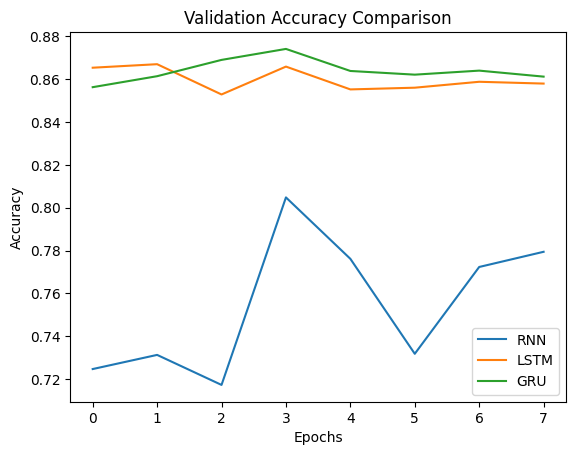

In [ ]:
plt.figure()

plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

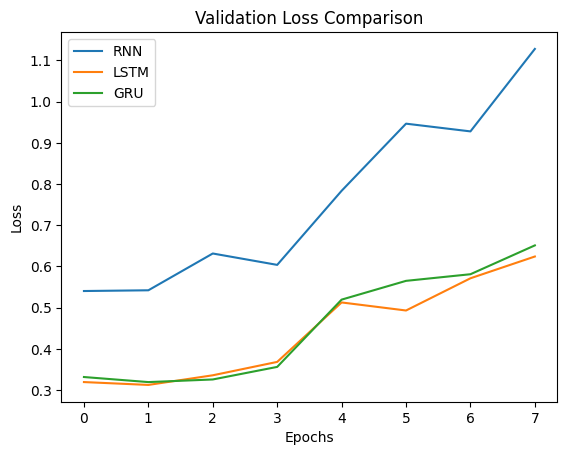

In [ ]:
plt.figure()

plt.plot(history_rnn.history['val_loss'], label='RNN')
plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.plot(history_gru.history['val_loss'], label='GRU')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()